# Práctica – Embeddings Semánticos con Sentence Transformers
## UNR · TUIA · Procesamiento de Lenguaje Natural – Unidad 2

En esta práctica trabajamos con **modelos de embeddings semánticos** densos
usando el modelo liviano `intfloat/multilingual-e5-small` (384 dimensiones, ~118 MB).

A diferencia de los métodos frecuentistas (TF-IDF, Count), estos embeddings
capturan el **significado semántico** del texto: dos frases con palabras
completamente distintas pero significados similares tendrán vectores cercanos.

| Parte | Tema |
|-------|------|
| 1 | Carga del dataset y preparación |
| 2 | Vectorización y almacenamiento en ZIP |
| 3 | Importación de embeddings desde ZIP |
| 4 | Búsqueda semántica de libros |
| 5 | Sistema de recomendación "Libros similares" |
| 6 | Análisis de similitud entre géneros |
| 7 | Clustering con K-Means |
| 8 | Visualización 2D/3D del espacio semántico |
| 9 | Evaluación comparativa: E5 vs TF-IDF |

> **Flujo de trabajo**: La Parte 2 vectoriza todo el dataset y guarda los embeddings
> en un archivo ZIP. A partir de la Parte 3, se importan desde el ZIP para no
> tener que re-vectorizar cada vez que se abre el notebook.


---
## 📌 Notas de esta resolución

- Solo se completó el cuerpo de cada función `TODO` y se descomentaron las llamadas que indica la consigna. El resto del notebook es el original.
- La línea `!pip install` de la primera celda es de Colab: localmente, las dependencias se instalan con el `requirements.txt` del repo.
- **La Parte 2 no se ejecutó.** Como dice la consigna ("si ya tenés el ZIP, saltá a la Parte 3"), se usó el ZIP de Drive. Las salidas de esas dos celdas son las originales de la consigna, corridas en Colab con GPU.

### ⚠️ Errores de consigna y problemas de los datos

1. **Tamaño del modelo:** la intro dice "~118 MB" y la tabla, "~450 MB en disco". Lo correcto es lo segundo: el modelo tiene ~118 **millones de parámetros**, que ocupan ~470 MB.
2. **Tiempo de vectorización:** la Parte 2 avisa que en CPU tarda "~5-10 minutos". En la máquina donde se resolvió, sin GPU, el modelo procesa unas 14 sinopsis por segundo: las 47.819 tardarían cerca de una hora.
3. **"No hace falta tener sentence-transformers ni el modelo para resolver los ejercicios"** (Parte 3): vale para los ejercicios 2 a 5. El 1 y el 6 codifican consultas nuevas, y para eso necesitan el modelo.
4. **`genero_principal` no es el género principal:** es el primero en orden alfabético, porque Lectulandia lista los géneros ordenados. "Intriga - Novela" queda como Intriga, y "Novela - Romántico", como Novela.
5. **Texto mal codificado:** 1.870 libros (3,9 %) tienen cosas como "Hist√≥rico" en lugar de "Histórico". Eso duplica 22 géneros: los 100 que informa la Parte 1 son, en realidad, 78. Se ve en los resultados (por ejemplo, "El universo en una taza de caf√©").
6. **Libros repetidos:** 683 libros aparecen dos veces (mismo título y autor), así que pueden ocupar dos lugares de un top 5, como en la tercera búsqueda del Ejercicio 1.

In [1]:
# ── Instalaciones (ejecutar una vez) ──────────────────────────────────────
# !pip install sentence-transformers scikit-learn numpy pandas matplotlib seaborn

# ── Imports globales ──────────────────────────────────────────────────────
import re, os, zipfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score, adjusted_rand_score
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100


---
# Parte 1 – Carga y Preparación del Dataset

Usamos el dataset de **Lectulandia** (~62k libros). Filtramos los que tienen
sinopsis y limpiamos el texto para la vectorización.


In [2]:
# ── Cargar dataset ────────────────────────────────────────────────────────
df_raw = pd.read_csv("data/lectulandia_books.csv")
print(f"Dataset original: {len(df_raw):,} libros, {df_raw.columns.tolist()}")
print(f"Libros sin sinopsis: {df_raw['sinapsis'].isna().sum():,}")

# Filtrar libros con sinopsis
df = df_raw.dropna(subset=["sinapsis"]).copy()
df = df[df["sinapsis"].str.strip().str.len() > 50].reset_index(drop=True)
print(f"Libros con sinopsis válida (>50 chars): {len(df):,}")

# Limpieza básica del texto
def limpiar_texto(texto):
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df["sinopsis_clean"] = df["sinapsis"].apply(limpiar_texto)

# Extraer género principal (el primero de la lista)
df["genero_principal"] = df["generos"].fillna("Sin género").apply(
    lambda x: x.split(" - ")[0].strip()
)

# Estadísticas rápidas
print(f"\nLongitud promedio de sinopsis: {df['sinopsis_clean'].str.len().mean():.0f} caracteres")
print(f"Géneros únicos (principal): {df['genero_principal'].nunique()}")
print(f"\nTop 10 géneros:")
print(df["genero_principal"].value_counts().head(10).to_string())

Dataset original: 62,279 libros, ['url', 'titulo', 'autor', 'autor_url', 'sinapsis', 'imagen_url', 'generos']
Libros sin sinopsis: 14,449
Libros con sinopsis válida (>50 chars): 47,819



Longitud promedio de sinopsis: 929 caracteres
Géneros únicos (principal): 100

Top 10 géneros:
genero_principal
Novela               9363
Intriga              5304
Histórico            3604
Drama                3305
Ensayo               2715
Aventuras            2506
Ciencia ficción      2440
Fantástico           2340
Ciencias sociales    2197
Crónica              2083


---
# Parte 2 – Vectorización con `intfloat/multilingual-e5-small` y Guardado en ZIP

## Sobre el modelo

`intfloat/multilingual-e5-small` es un modelo de embeddings multilingüe entrenado
con la técnica E5 (*EmbEddings from tExtual data with Text-to-text format*).

| Propiedad | Valor |
|-----------|-------|
| Dimensiones | 384 |
| Parámetros | ~118M |
| Idiomas | 100+ (incluye español) |
| Tamaño en disco | ~450 MB |
| Velocidad | Rápido en CPU |

**Importante**: E5 usa un prefijo para indicar el tipo de texto:
- `"query: "` para consultas de búsqueda
- `"passage: "` para documentos/pasajes a indexar

Esto mejora la calidad de los embeddings significativamente.

> **Esta celda tarda ~5-10 minutos en CPU para el dataset completo (~48k libros).** Los embeddings se guardan en un ZIP
> para no tener que repetir este paso. Si ya tenés el ZIP, saltá a la Parte 3.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CELDA DE VECTORIZACIÓN — Ejecutar UNA vez, luego usar el ZIP
# ══════════════════════════════════════════════════════════════════════════
from sentence_transformers import SentenceTransformer
import time

MODEL_NAME = "intfloat/multilingual-e5-small"
model = SentenceTransformer(MODEL_NAME)

# Preparar textos con el prefijo "passage:" que usa E5
textos_para_encode = ["passage: " + t for t in df["sinopsis_clean"].tolist()]

print(f"Vectorizando {len(textos_para_encode):,} sinopsis con {MODEL_NAME}...")
print(f"Esto puede tardar ~5-10 minutos en CPU...")

t0 = time.time()
embeddings = model.encode(
    textos_para_encode,
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True
)
elapsed = time.time() - t0

print(f"\nVectorización completada en {elapsed:.1f}s")
print(f"Shape de embeddings: {embeddings.shape}")
print(f"Tipo: {embeddings.dtype}")
print(f"Norma L2 promedio: {np.linalg.norm(embeddings, axis=1).mean():.4f}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23979.16it/s]
BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vectorizando 47,819 sinopsis con intfloat/multilingual-e5-small...
Esto puede tardar ~5-10 minutos en CPU...


Batches: 100%|██████████| 748/748 [00:46<00:00, 16.24it/s]


Vectorización completada en 46.7s
Shape de embeddings: (47819, 384)
Tipo: float32
Norma L2 promedio: 1.0000


### Guardar embeddings y metadata en ZIP

Guardamos en un archivo ZIP:
- `embeddings.npy` — la matriz numpy de embeddings (shape: N x 384)
- `metadata.csv` — información de cada libro (título, autor, género, sinopsis)
- `config.json` — configuración del modelo y parámetros usados

Así cualquier celda posterior puede importar todo sin necesidad de re-vectorizar.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# GUARDAR EMBEDDINGS EN ZIP
# ══════════════════════════════════════════════════════════════════════════
import json

ZIP_PATH = "data/embeddings_e5_small.zip"

# Preparar metadata
df_meta = df[["titulo", "autor", "sinopsis_clean", "genero_principal", "generos"]].copy()
df_meta.columns = ["titulo", "autor", "sinopsis", "genero_principal", "generos"]

# Configuración
config = {
    "model_name": MODEL_NAME,
    "embedding_dim": int(embeddings.shape[1]),
    "n_documents": int(embeddings.shape[0]),
    "normalized": True,
    "prefix_used": "passage: ",
    "dtype": str(embeddings.dtype),
}

# Guardar en ZIP
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    # Embeddings como .npy
    buf = io.BytesIO()
    np.save(buf, embeddings)
    zf.writestr("embeddings.npy", buf.getvalue())

    # Metadata como CSV
    csv_buf = io.StringIO()
    df_meta.to_csv(csv_buf, index=False)
    zf.writestr("metadata.csv", csv_buf.getvalue())

    # Config como JSON
    zf.writestr("config.json", json.dumps(config, indent=2, ensure_ascii=False))

file_size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f"Guardado en: {ZIP_PATH}")
print(f"   Tamaño: {file_size_mb:.1f} MB")
print(f"   Contenido:")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    for info in zf.infolist():
        print(f"     - {info.filename}: {info.file_size / 1024:.1f} KB")

Guardado en: data/embeddings_e5_small.zip
   Tamaño: 81.8 MB
   Contenido:
     - embeddings.npy: 71728.6 KB
     - metadata.csv: 47969.9 KB
     - config.json: 0.2 KB


---
# Parte 3 – Importar Embeddings desde ZIP

> **A partir de acá, todas las celdas usan los embeddings pre-calculados.**
> No hace falta tener `sentence-transformers` instalado ni el modelo descargado
> para resolver los ejercicios — solo el archivo ZIP.

Si no generaste el ZIP, podés descargarlo desde [Google Drive](https://drive.google.com/file/d/1SxsCy9airq_1OaNKFVUu_SB7HGSTe_gk/view?usp=sharing) y colocarlo en `data/embeddings_e5_small.zip`.

Ejecutá la siguiente celda para cargar embeddings y metadata.

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# IMPORTAR EMBEDDINGS DESDE ZIP — Ejecutar siempre
# ══════════════════════════════════════════════════════════════════════════
import zipfile, io, json
import numpy as np
import pandas as pd

ZIP_PATH = "data/embeddings_e5_small.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    # Cargar embeddings
    with zf.open("embeddings.npy") as f:
        embeddings = np.load(io.BytesIO(f.read()))

    # Cargar metadata
    with zf.open("metadata.csv") as f:
        df_libros = pd.read_csv(io.BytesIO(f.read()))

    # Cargar config
    with zf.open("config.json") as f:
        config = json.loads(f.read())

print(f"Embeddings cargados desde ZIP")
print(f"   Modelo: {config['model_name']}")
print(f"   Documentos: {embeddings.shape[0]:,}")
print(f"   Dimensiones: {embeddings.shape[1]}")
print(f"   Normalizados: {config['normalized']}")
print(f"\nPrimeras filas del dataset:")
df_libros.head()

Embeddings cargados desde ZIP
   Modelo: intfloat/multilingual-e5-small
   Documentos: 47,819
   Dimensiones: 384
   Normalizados: True

Primeras filas del dataset:


,titulo,autor,sinopsis,genero_principal,generos
0,Tierra feroz,Jota Quijorna,La oscuridad de un alma herida es el hogar de ...,Intriga,Intriga - Novela
1,Tehanu,Ursula K. Le Guin,"El mal medra, y la magia se ha pervertido. En ...",Fantástico,Fantástico - Novela
2,El niño del taxi,Sylvain Prudhomme,"Durante el funeral de su abuelo, Simon descubr...",Histórico,Histórico - Novela
3,James Bond 007: El juego de rol,Gerard Christopher Klug,ATRÉVETE A VIVIR EN EL FASCINANTE MUNDO DE JAM...,Juegos,Juegos - Manuales y cursos - Referencia
4,El retorno del cuervo,Alissa Brontë,"Tras varios años alejado del que fue su hogar,...",Histórico,Histórico - Novela - Romántico


---
# Parte 4 – Búsqueda Semántica de Libros

Los embeddings semánticos permiten buscar libros por **significado**, no por
palabras clave exactas.

### Ejercicio 1 – Búsqueda Semántica por Texto

Implementá `buscar_libros` que reciba una query en lenguaje natural y
devuelva los N libros más relevantes usando similitud coseno.

**Recordá** que E5 usa el prefijo `"query: "` para las consultas.

In [4]:
def buscar_libros(query, embeddings, df_libros, model, n=5):
    """
    TODO:
    1. Codificar la query con model.encode() usando prefijo "query: "
    2. Calcular cosine_similarity contra todos los embeddings
    3. Retornar los top-N como DataFrame (titulo, autor, genero_principal, score)
    """
    # 1. Codificar la query con el prefijo de E5. normalize_embeddings=True la deja
    #    con norma 1, como los embeddings del ZIP
    vector_query = model.encode(["query: " + query], normalize_embeddings=True)

    # 2. Similitud coseno contra todos los libros: un score por libro
    scores = cosine_similarity(vector_query, embeddings)[0]

    # 3. Los n scores más altos (argsort ordena de menor a mayor; [::-1] lo invierte)
    top = np.argsort(scores)[::-1][:n]
    resultado = df_libros.iloc[top][["titulo", "autor", "genero_principal"]].copy()
    resultado["score"] = scores[top].round(3)
    return resultado


queries_test = [
    "historia de amor en tiempos de guerra",
    "aventuras de fantasía con dragones y magia",
    "divulgación científica sobre el universo",
]

# Descomentar cuando implementes:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("intfloat/multilingual-e5-small")
for q in queries_test:
    print(f"\n «{q}»")
    print(buscar_libros(q, embeddings, df_libros, model).to_string(index=False))


 «historia de amor en tiempos de guerra»
                           titulo         autor genero_principal  score
             La mujer del Coronel   Rosa Liksom            Drama  0.886
                        El auriga  Mary Renault            Drama  0.880
                   Tiempo que fue  Ian McDonald Ciencia ficci√≥n  0.879
La guardiana de recuerdos de Kyiv Erin Litteken            Drama  0.878
                   Tinta y ceniza   Andrea Tomé        Histórico  0.878

 «aventuras de fantasía con dragones y magia»


                                titulo          autor genero_principal  score
                    La pluma del grifo Cornelia Funke       Fantástico  0.885
    Los mejores relatos de fantasía II    Alan Garner       Fantástico  0.871
                     El ojo del dragón    Dave Morris        Aventuras  0.870
The Dragon Nindenn-Ka-Yh: Renacimiento  David Cabrera       Fantástico  0.869
              El libro de los dragones Varios Autores        Aventuras  0.869

 «divulgación científica sobre el universo»
                          titulo          autor   genero_principal  score
  Guía de la Tierra y el espacio   Isaac Asimov Ciencias naturales  0.890
El universo en una taza de caf√©  Jordi Pereyra Ciencias naturales  0.881
El universo en una taza de caf√©  Jordi Pereyra Ciencias naturales  0.881
               Universos ocultos   Lisa Randall   Ciencias exactas  0.877
         El universo en una caja Andrew Pontzen         Astronomía  0.875


---
# Parte 5 – Libros Similares (sin modelo)

Dado un libro del dataset, encontrar los más parecidos usando solo los
embeddings precalculados. **No requiere cargar el modelo.**

### Ejercicio 2 – Encontrar Libros Similares

Implementá `libros_similares` que dado el índice de un libro retorne
los N más parecidos (excluyéndose a sí mismo).

In [5]:
def libros_similares(idx, embeddings, df_libros, n=5):
    """
    TODO:
    1. Obtener el embedding del libro en posición idx
    2. Calcular cosine_similarity contra todos los embeddings
    3. Excluir el propio libro
    4. Retornar DataFrame con: titulo, autor, genero_principal, score
    """
    # 1-2. Similitud del libro contra todos. embeddings[idx:idx + 1] (y no embeddings[idx])
    #      conserva la forma de matriz de una fila que espera cosine_similarity
    scores = cosine_similarity(embeddings[idx:idx + 1], embeddings)[0]

    # 3. Excluir el propio libro: su similitud consigo mismo es 1 y saldría primero
    scores[idx] = -1

    # 4. Los n más parecidos
    top = np.argsort(scores)[::-1][:n]
    resultado = df_libros.iloc[top][["titulo", "autor", "genero_principal"]].copy()
    resultado["score"] = scores[top].round(3)
    return resultado

libro = df_libros.iloc[0]
print(f"Similares a «{libro['titulo']}»:")
print(libros_similares(0, embeddings, df_libros))

Similares a «Tierra feroz»:
                        titulo                autor genero_principal  score
40192          Desde la sombra     Juan José Millás            Humor  0.900
46     Lo que oculta la tierra       Leticia Sierra           Novela  0.895
20898  La leyenda del desierto  Carlos Egia Ossorio          Intriga  0.894
19434             La forastera          Olga Merino           Novela  0.894
1652          Ojos color limón        Marta Simonet           Novela  0.893


---
# Parte 6 – Similitud entre Géneros

Calculando el **embedding promedio** de cada género podemos medir qué tan
parecidos son los géneros entre sí.

**Importante**: Antes de calcular centroides, hay que **centrar los embeddings**
restando la media global. Sin esto, todos los centroides quedan con similitud
~0.98 porque comparten un componente común ("es una sinopsis de libro en español").

### Ejercicio 3 – Heatmap de Similitud entre Géneros

1. **Centrar** los embeddings (restar la media global)
2. Filtrar los géneros con al menos 1000 libros
3. Calcular el centroide (promedio de embeddings centrados) de cada género
4. Armar la matriz de similitud coseno entre centroides
5. Mostrar como heatmap

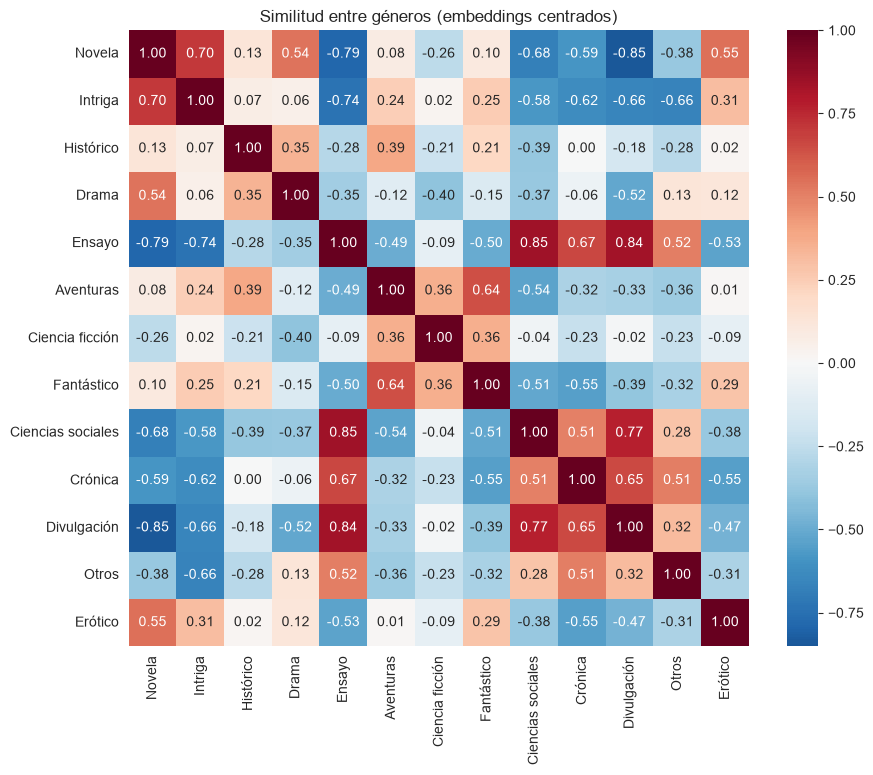

In [6]:
def similitud_generos(embeddings, df_libros, min_libros=1000):
    """
    TODO:
    1. Centrar embeddings: restar la media global (embeddings - embeddings.mean(axis=0))
    2. Filtrar géneros con >= min_libros
    3. Calcular centroide por género (promedio de embeddings centrados, normalizar)
    4. Calcular cosine_similarity entre centroides
    5. Graficar heatmap con sns.heatmap
    """
    # 1. Centrar: restar a cada embedding el vector promedio de todo el corpus
    centrados = embeddings - embeddings.mean(axis=0)

    # 2. Géneros con al menos min_libros libros
    conteo = df_libros["genero_principal"].value_counts()
    generos = conteo[conteo >= min_libros].index

    # 3. Centroide de cada género: el promedio de sus embeddings centrados, llevado a norma 1
    centroides = []
    for genero in generos:
        filas = (df_libros["genero_principal"] == genero).to_numpy()
        centroide = centrados[filas].mean(axis=0)
        centroides.append(centroide / np.linalg.norm(centroide))

    # 4. Similitud coseno entre todos los pares de centroides: matriz de géneros × géneros
    similitud = cosine_similarity(np.array(centroides))

    # 5. Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(similitud, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                xticklabels=generos, yticklabels=generos)
    plt.title("Similitud entre géneros (embeddings centrados)")
    plt.show()

similitud_generos(embeddings, df_libros)

---
# Parte 7 – Clustering con K-Means

¿Los embeddings agrupan naturalmente los libros por género?
Probemos con K-Means y visualicemos con PCA.

### Ejercicio 4 – Clustering sobre Embeddings

1. Filtrar los **top 5 géneros** más frecuentes
2. Aplicar K-Means (K=5) sobre los embeddings
3. Calcular **Silhouette Score**
4. Visualizar en 2D con PCA, coloreando por cluster

24,291 libros de ['Novela', 'Intriga', 'Histórico', 'Drama', 'Ensayo']
Silhouette score: 0.007


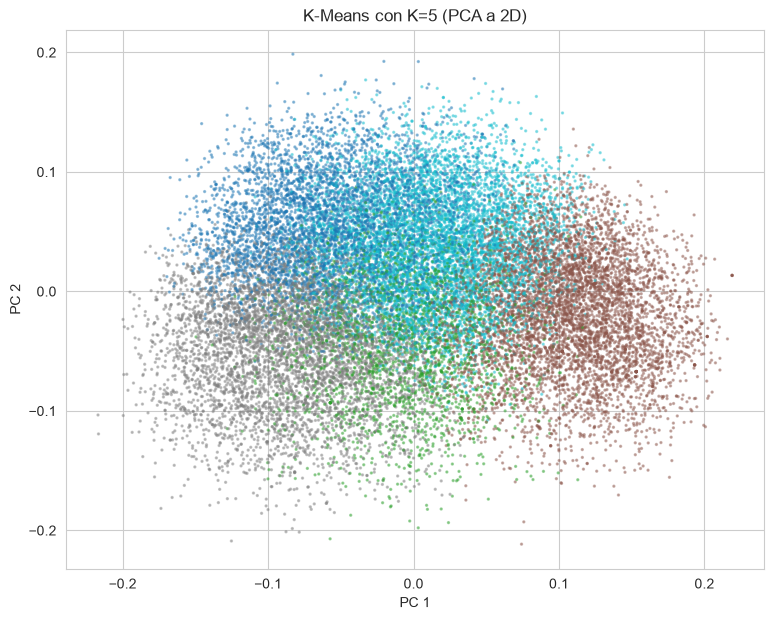

In [7]:
def clustering_embeddings(embeddings, df_libros, n_generos=5):
    """
    TODO:
    1. Filtrar top n_generos más frecuentes
    2. Aplicar KMeans(n_clusters=n_generos) sobre sus embeddings
    3. Calcular silhouette_score
    4. PCA a 2D y scatter plot coloreado por cluster
    """
    # 1. Libros de los n géneros más frecuentes
    top = df_libros["genero_principal"].value_counts().head(n_generos).index
    filas = df_libros["genero_principal"].isin(top).to_numpy()
    X = embeddings[filas]

    # 2. K-Means: agrupa los libros en n_generos clusters.
    #    n_init=10 lo corre 10 veces con distintos puntos de partida y se queda con el mejor
    kmeans = KMeans(n_clusters=n_generos, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)

    # 3. Silhouette: va de -1 a 1, y cerca de 0 indica clusters superpuestos.
    #    Compara todos los pares de libros, así que se estima con una muestra de 5.000
    silhouette = silhouette_score(X, clusters, sample_size=5000, random_state=42)
    print(f"{len(X):,} libros de {list(top)}")
    print(f"Silhouette score: {silhouette:.3f}")

    # 4. PCA a 2D, coloreado por cluster
    X_2d = PCA(n_components=2, random_state=42).fit_transform(X)
    plt.figure(figsize=(9, 7))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="tab10", s=2, alpha=0.4)
    plt.title(f"K-Means con K={n_generos} (PCA a 2D)")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.show()

clustering_embeddings(embeddings, df_libros)

---
# Parte 8 – Visualización del Espacio Semántico

Reducimos 384 dimensiones a 2D para ver cómo se distribuyen los libros.

### Ejercicio 5 – Mapa Semántico con PCA

1. Filtrar los **top 8 géneros**
2. Aplicar PCA a 2D
3. Scatter plot coloreado por género con leyenda

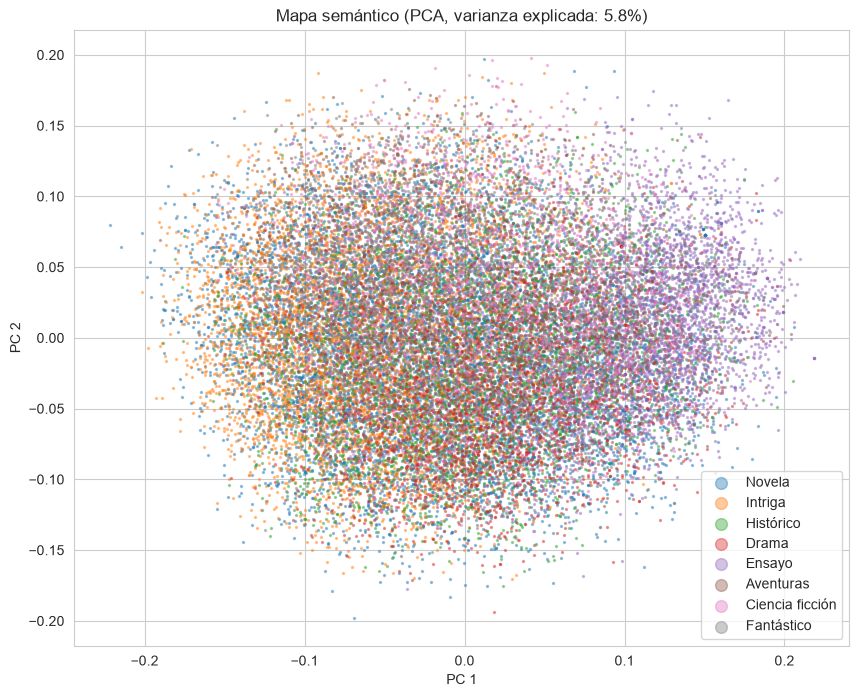

In [8]:
def mapa_semantico(embeddings, df_libros, n_generos=8):
    """
    TODO:
    1. Filtrar top n_generos
    2. PCA a 2D
    3. Scatter plot con colores por género y leyenda
    """
    # 1. Libros de los n géneros más frecuentes
    top = df_libros["genero_principal"].value_counts().head(n_generos).index
    filas = df_libros["genero_principal"].isin(top).to_numpy()
    generos = df_libros.loc[filas, "genero_principal"].to_numpy()

    # 2. PCA a 2D
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(embeddings[filas])

    # 3. Scatter con un color por género
    plt.figure(figsize=(10, 8))
    for genero in top:
        m = generos == genero
        plt.scatter(X_2d[m, 0], X_2d[m, 1], s=2, alpha=0.4, label=genero)
    plt.legend(markerscale=6)
    # explained_variance_ratio_: proporción de la varianza que conserva cada componente
    plt.title(f"Mapa semántico (PCA, varianza explicada: {pca.explained_variance_ratio_.sum():.1%})")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.show()

mapa_semantico(embeddings, df_libros)

---
# Parte 9 – Comparativa: E5 vs TF-IDF

¿Qué tan distintos son los resultados de una búsqueda semántica (E5)
vs una búsqueda por palabras clave (TF-IDF)?

### Ejercicio 6 – E5 vs TF-IDF en Búsqueda

1. Vectorizar las sinopsis con `TfidfVectorizer`
2. Para 5 queries, buscar top-5 con ambos métodos
3. Contar cuántos resultados tienen en común (overlap)

In [9]:
def comparar_e5_tfidf(embeddings, df_libros, model):
    """
    TODO:
    1. Crear TfidfVectorizer y vectorizar sinopsis
    2. Para cada query: buscar top-5 con E5 y con TF-IDF
    3. Calcular overlap (cuántos libros en común de los 5)
    4. Imprimir resultados lado a lado
    """
    # 1. TF-IDF sobre las mismas sinopsis
    tfidf = TfidfVectorizer()
    X_tfidf = tfidf.fit_transform(df_libros["sinopsis"])

    queries = [
        "historia de amor en tiempos de guerra",
        "aventuras de fantasía con dragones y magia",
        "divulgación científica sobre el universo",
        "un detective investiga un asesinato en un pueblo pequeño",
        "un relato de bucaneros en el Caribe",
    ]

    for query in queries:
        # 2. Top-5 con cada método (la query de TF-IDF va sin el prefijo de E5)
        top_e5 = buscar_libros(query, embeddings, df_libros, model, n=5)
        scores_tfidf = cosine_similarity(tfidf.transform([query]), X_tfidf)[0]
        top_tfidf = np.argsort(scores_tfidf)[::-1][:5]

        # 3. Overlap: libros que aparecen en los dos top-5 (se comparan por su fila en df_libros)
        en_comun = set(top_e5.index) & set(df_libros.index[top_tfidf])

        # 4. Lado a lado
        print(f"\n«{query}» — libros en común: {len(en_comun)} de 5")
        tabla = pd.DataFrame({
            "E5": top_e5["titulo"].str[:40].values,
            "TF-IDF": df_libros["titulo"].iloc[top_tfidf].str[:40].values,
        })
        print(tabla.to_string(index=False))

comparar_e5_tfidf(embeddings, df_libros, model)


«historia de amor en tiempos de guerra» — libros en común: 0 de 5
                               E5                        TF-IDF
             La mujer del Coronel                    Desertores
                        El auriga         El color del silencio
                   Tiempo que fue       La voz de los valientes
La guardiana de recuerdos de Kyiv La Mansión. Tiempos gloriosos
                   Tinta y ceniza       La vida después de ella



«aventuras de fantasía con dragones y magia» — libros en común: 0 de 5
                                    E5                                   TF-IDF
                    La pluma del grifo Tiempo de dragones. La profecía imperfec
    Los mejores relatos de fantasía II                   Las crónicas del mundo
                     El ojo del dragón                      La garra del dragón
The Dragon Nindenn-Ka-Yh: Renacimiento                               Más Allá 1
              El libro de los dragones                   La profecía imperfecta



«divulgación científica sobre el universo» — libros en común: 1 de 5
                              E5                               TF-IDF
  Guía de la Tierra y el espacio                         Penumbria 24
El universo en una taza de caf√© El electrón es zurdo y otros ensayos
El universo en una taza de caf√©    Carl Sagan. Una vida en el cosmos
               Universos ocultos                           Más Allá 1
         El universo en una caja       Guía de la Tierra y el espacio



«un detective investiga un asesinato en un pueblo pequeño» — libros en común: 0 de 5
                      E5                     TF-IDF
        Secretos ocultos    El nacimiento de Cupido
  La araña y la mariposa     No uses anillo de boda
Preludio para una muerte                 Paso fatal
   Una revelación brutal Dos nombres para la muerte
           No digas nada        Sombras en la noche



«un relato de bucaneros en el Caribe» — libros en común: 1 de 5
                         E5                     TF-IDF
                     Caribe                     Caribe
La república de los piratas    El libro de los piratas
       Cazadores de piratas       Biografía del Caribe
  Ramage y los filibusteros El príncipe de los piratas
              La última ola      Los dueños del viento


---
# Resumen

| Aspecto | TF-IDF | E5-small (Sentence Transformer) |
|---------|--------|---------------------------------|
| **Tipo de vector** | Sparse, alta dimensión | Denso, 384 dims |
| **Semántica** | Léxica (palabras exactas) | Contextual (significado) |
| **Multilingüe** | No | Sí (100+ idiomas) |
| **Velocidad** | Muy rápido | Moderado |
| **Mejor para** | Búsqueda por keywords | Búsqueda por significado |

### Flujo recomendado

1. **Vectorizar una vez** con el modelo E5
2. **Guardar en ZIP** para reutilizar
3. **Importar embeddings** sin necesidad del modelo
4. Solo cargar el modelo para **queries nuevas**